In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import traceback

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from tqdm import tqdm

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
import generator_core as core
from aspect_midnight import Midnight

In [4]:
create_dataset = False

In [5]:
try:
    # print(core.genius_lyrics.file_name)
    ds_genius = lambda: core.genius_lyrics.open_as_df()

    if create_dataset:
        for ds_batch in ds_genius():
            display(ds_batch.head())
            break
except:
    traceback.print_exc()

In [6]:
try:
    batch_count = 0
    genres = set()
    if create_dataset and False:
        for ds_batch in ds_genius():
            batch_count += 1
            genres.update(ds_batch['tag'].unique())
    else:
        batch_count = 103
        genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'pop', 'country', 'rap', 'misc', 'rock', 'rb'}
103


In [7]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50

    if create_dataset:
        genre_groups = {}
        artist_counts = {}

        pbar = tqdm(total=batch_count)
        for ds_batch in ds_genius():
            pbar.update(1)
            ds_batch = ds_batch.drop(columns=['views', 'features', 'language_cld3', 'language_ft'])
            ds_batch = ds_batch[ds_batch['language'] == 'en'].sample(frac=1)
            ds_batch['length'] = ds_batch['lyrics'].apply(len)
            ds_batch = ds_batch[(ds_batch['length'] >= 1000) & (ds_batch['length'] <= 3000)]

            for genre in genres:
                group = genre_groups.get(genre, pd.DataFrame())
                if len(group) >= total_group_size: continue

                ds_batch = ds_batch[ds_batch['tag'] == genre]
                for artist, a_group in ds_batch.groupby('artist'):
                    existing_count = artist_counts.get(artist, 0)
                    if existing_count >= max_songs_per_artist: continue
                    new_sample = min(len(a_group), max_songs_per_artist - existing_count)
                    subset = a_group.sample(new_sample).drop(columns=['length'])
                    group = pd.concat([group, subset])
                    artist_counts[artist] = existing_count + new_sample

                if len(group) >= total_group_size: group = group.sample(total_group_size)
                genre_groups[genre] = group

            if all([len(group) >= total_group_size for group in genre_groups.values()]): break

        for genre, group in genre_groups.items():
            print(genre, len(group))

        print("Unique Artists", len(artist_counts))
        print("Avg Songs/Artists", np.mean(list(artist_counts.values())))

    else:
        print("misc 16667\nrap 16667\nrb 16667\npop 16667\ncountry 16667\nrock 16667\nUnique Artists 36067\nAvg Songs/Artists 2.7726")
except:
    traceback.print_exc()

misc 16667
rap 16667
rb 16667
pop 16667
country 16667
rock 16667
Unique Artists 36067
Avg Songs/Artists 2.7726


In [8]:
try:
    if create_dataset:
        ds_subset = pd.concat(list(genre_groups.values())).sample(frac=1)
        ds_subset.to_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
        del genre_groups
    else:
        ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
        display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [9]:
try:
    _t = ds_subset.sample(1)
    print("INDEX: ", _t.index[0])
    print(_t['lyrics'].values[0])
except:
    traceback.print_exc()

INDEX:  8984
The NSA identified domestic targets based on leads that were often derived from the seizure of Qaeda computers and cell phones overseas. If, for example, al Qaeda cell phone seized in Pakistan had dialed a phone number in the United States, the NSA would target the U.S. phone number—which would then lead agents to look at other numbers in the United States and abroad called by the targeted phone. Other parts of the program were far more sweeping. The NSA, with the secret cooperation of U.S. telecommunications companies, had begun collecting vast amounts of information about the phone and e-mail records of American citizens. Separately, the NSA was also able to access, for the first time, massive volumes of personal financial records—such as credit-card transactions, wire transfers and bank withdrawals—that were being reported to the Treasury Department by financial institutions. These included millions of “suspicious-activity reports,” or SARS, according to two former Trea

In [10]:
# There are named speech tags of form "(Devyn)" and "(Simon)"
# Other conventions like "[Hook]" and "[Pre-Hook]"
# Some crazy format issues too like "[Hook ]"
# Sometimes the first line is the song title
# And then there is just text in [] like "[See, everybody ...211 chars total... the same fr]"
# There are also numbered versions like "[Verse 1]"
# 4314672: Wow, there are even URLS like "https://www.rapidbooster.net/". In fact there is no song at all
# 101494 : has "[Verse 1: Michael Jackson]"
# 46815  : has "[Chorus: Slug and Murs]", "[Murs]", "[Slug]"
# 28520  : has "[Frank Sinatra sample]", "[Hook 2X][Frank Sinatra](Kids)", and other text in () and []
# 8889   : has an unclosed [ in the start
# 1459482: has both "(Chorus)" and "Chorus:"
# 2944086: has "[October 31st, 2004]"
# 22005  : has it's verses separated as I, II, III...

In [11]:
try:
    midnight = Midnight(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded Cache for Midnight._prepare_language_model.cached


In [12]:
try:
    for sample in midnight.ds_data.itertuples():
        print(sample.tag)
        print(midnight.get_context_words(sample.lyrics))
        print(midnight.tokenize_text(midnight.get_context_words(sample.lyrics)))
        break
except:
    traceback.print_exc()

misc
['instruments', 'ireland', 'survives', 'day', 'poetry']
[[5789, 26], [7076], [1242, 26], [144], [2740]]


In [13]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    for sample in ds_subset.sample(1).itertuples():
        print("INDEX", sample.id)
        print("ORIGINAL")
        print(sample.lyrics)
        print("PROCESSED")
        print(midnight.clean_text(sample.lyrics))
except:
    traceback.print_exc()

INDEX 3116182
ORIGINAL
[Verse 1]
It's so unusual it's frightening
You see right through the mess inside me
And you call me out to pull me in
You tell me I can start again
And I don't need to keep on hiding

[Chorus]
I'm fully known and loved by You
You won't let go no matter what I do
And it's not one or the other
It's hard truth and ridiculous grace
To be known fully known and loved by You
I'm fully known and loved by You

[Verse 2]
It's so like You to keep pursuing
It's so like me to go astray
But You guard my heart with Your truth
A kind of love that's bullet proof
And I surrender to Your kindness
[Chorus]
I'm fully known and loved by You
You won't let go no matter what I do
And it's not one or the other
It's hard truth and ridiculous grace
To be known fully known and loved by You
I'm fully known and loved by You

[Bridge]
How real, how wide
How rich, how high is Your heart
I cannot find the reasons why
You give me so much
How real, how wide
How rich, how high is Your heart
I cannot

In [14]:
try:
    print(midnight.custom_tokens)
except:
    traceback.print_exc()

{'<SONG_START>', '<STANZA>', '<HOOK>', '<INTRO>', '<VERSE>', '<CHORUS>', '<OUTRO>', '<NEW_LINE>', '<BRIDGE>', '<SONG_END>', '<INTERLUDE>'}


In [15]:
try:
    print(midnight.feature_names.shape)
    print(np.random.choice(midnight.feature_names, 10))
except:
    traceback.print_exc()

(50000,)
['toni' 'outerspace' 'diseased' 'axle' 'author' "til'" 'dinna' 'hock'
 'exaltations' 'consequences']


In [16]:
try:
    # for sample in ds_subset[ds_subset['id'] == 1856105].itertuples():
    lengths = ds_subset['lyrics'].apply(len)
    print(lengths.min(), lengths.max(), lengths.mean())
    del lengths
except:
    traceback.print_exc()

1000 3000 1670.2838243235135


In [17]:
try:
    display(midnight.annotate_text(2))
except:
    traceback.print_exc()

Annotation(lyrics_id=2, genre='pop', keywords=['pull', 'blame', 'love', 'played', 'falling'])

In [18]:
try:
    print("Vocab Size: ", midnight.vocabulary.vocab_size())
    print(midnight.tokenize_text("pneumonoultramicroscopicsilicovolcanoconiosis"))
    print(midnight.tokenize_text("entertainment"))
    print(midnight.tokenize_text("entertaimnent"))
    print(midnight.tokenize_text("<CHORUS>"))
    print(midnight.tokenize_text("<SONG_START>"))
    print(midnight.tokenize_text("<SONG_END>"))
    print(midnight.tokenize_text("<NEW_LINE>"))
except:
    traceback.print_exc()

Vocab Size:  16000
[807, 1271, 936, 1382, 7642, 3653, 39, 954, 1600, 26, 1696, 11162, 26, 7090, 1696, 2164, 8881, 5783, 2863, 517, 11896]
[5807]
[1508, 1705, 3598, 297, 2417]
[14, 7]
[14, 11]
[14, 3]
[17, 13, 19, 15, 20, 18, 13, 16]


In [19]:
try:
    word2vec = midnight.embedder
    print(word2vec)
except:
    traceback.print_exc()

Word2Vec_SkipGram(
  (embeddings): Embedding(16000, 512)
  (linear): Linear(in_features=512, out_features=16000, bias=True)
)


In [ ]:
try:
    train_word2vec = True

    if train_word2vec:
        # word2vec.dataloader = data.DataLoader(
        #     word2vec.dataloader.dataset,
        #     batch_size=20,
        #     shuffle=True,
        #     collate_fn=word2vec.collate_fn,
        # )
        # word2vec.trainer.train_dataloader = word2vec.dataloader
        word2vec.trainer.device = 'cuda'
        word2vec.trainer.checkpoint_frequency_batch = 3
        # for pg in word2vec.trainer.optimizer.param_groups:
        #     pg['lr'] = 0.0003
        # word2vec.trainer.optimizer = optim.AdamW(
        #     word2vec.parameters(),
        #     lr=0.0003,
        #     betas=(0.95, 0.9999)
        # )
        word2vec.trainer.optimizer = optim.SGD(
            word2vec.parameters(),
            lr=0.001,
            momentum=0.99
        )
except:
    traceback.print_exc()

In [ ]:
try:
    if train_word2vec:
        word2vec.train_model()
    # CPU Time = 4.11 seconds average
    # GPU Time = 1.00 seconds average
except:
    word2vec.trainer.optimizer.zero_grad()
    torch.cuda.empty_cache()
    traceback.print_exc()

In [ ]:
try:
    if train_word2vec:
        timers = word2vec.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

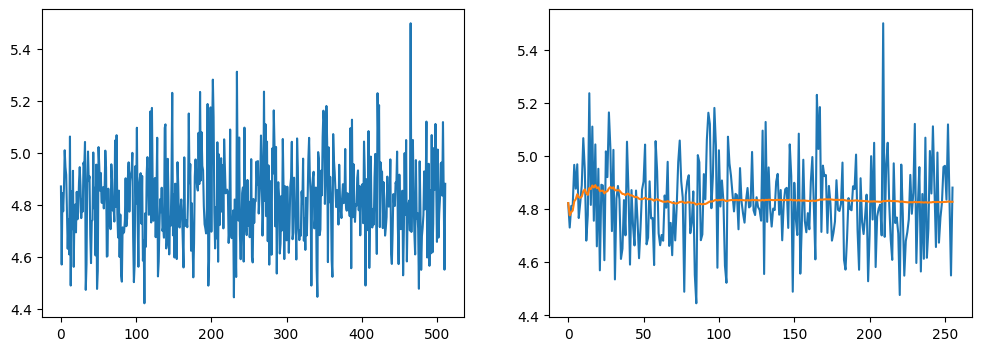

In [58]:
try:
    def running_average(nums):
        nums = np.asarray(nums, dtype=float)
        kernel = np.ones(len(nums))
        cumsum = np.convolve(nums, kernel, mode='full')[:len(nums)]
        counts = np.arange(1, len(nums) + 1)
        return cumsum / counts


    if train_word2vec:
        loss = word2vec.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        axs[1].plot(running_average(loss['train.batch'][int(0.5 * len(loss['train.batch'])):]))
        plt.show()
except:
    traceback.print_exc()

In [53]:
try:
    # loss['train.batch'] = loss['train.batch'][-100:]
    print(len(loss['train.batch']))
except:
    traceback.print_exc()

100


In [15]:
try:
    if train_word2vec:
        rewrite_embedder_cache = True
        if rewrite_embedder_cache:
            flight = 'Midnight._prepare_embedder.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: word2vec, group='Midnight._prepare_embedder')
            print("Done")
except:
    traceback.print_exc()

Done


In [20]:
try:
    if train_word2vec:
        midnight.embedder = word2vec
except:
    traceback.print_exc()

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_14116\1481184823.py", line 2, in <module>
    if train_word2vec:
       ^^^^^^^^^^^^^^
NameError: name 'train_word2vec' is not defined


In [21]:
try:
    for _word_a, _word_b, _word_c in (
            ("i", "am", "you"),
            ("girl", "lady", "man"),
            ("life", "happy", "sad"),
    ):
        _embeds_a = midnight.embed_tokens(_word_a).flatten()
        _embeds_b = midnight.embed_tokens(_word_b).flatten()
        _embeds_c = midnight.embed_tokens(_word_c).flatten()
        print(_embeds_a.shape, _embeds_b.shape, _embeds_c.shape)
        print(_word_a, _word_b, np.dot(_embeds_a, _embeds_b) / np.linalg.norm(_embeds_a) / np.linalg.norm(_embeds_b))
        print(_word_a, _word_c, np.dot(_embeds_a, _embeds_c) / np.linalg.norm(_embeds_a) / np.linalg.norm(_embeds_c))
        print()
except:
    traceback.print_exc()

(512,) (512,) (512,)
i am 0.17995341
i you 0.574814

(512,) (512,) (512,)
girl lady 0.37505034
girl man 0.38754705

(512,) (512,) (512,)
life happy 0.18779053
life sad 0.07679332



In [22]:
try:
    train_language_model = True

    if train_language_model:
        midnight.language_model = midnight.language_model

    print(midnight.language_model)
    print("Parameter Count", midnight.get_language_model_parameter_count())
except:
    traceback.print_exc()

ConditionalLSTMLM(
  (embedding): Embedding(16000, 512, padding_idx=0)
  (genre_embedding): Embedding(6, 64)
  (condition_proj_h): Linear(in_features=576, out_features=384, bias=True)
  (condition_proj_c): Linear(in_features=576, out_features=384, bias=True)
  (lstm): LSTM(512, 384, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=384, out_features=16000, bias=True)
)
Parameter Count 9165568


In [22]:
try:
    train_language_model = True

    if train_language_model:
        midnight.language_model.trainer.device = 'cuda'
        for pg in midnight.language_model.trainer.optimizer.param_groups:
            pg['lr'] = 0.0003
            print(pg['lr'])
        midnight.language_model.embedding.weight.requires_grad = True
        print(midnight.language_model.embedding.weight.requires_grad)

        # midnight.language_model.dataloader = data.DataLoader(
        #     midnight.language_model.dataloader.dataset,
        #     batch_size=8,  # 96
        #     shuffle=True,
        #     collate_fn=midnight.language_model.dataloader.collate_fn,
        # )
        # midnight.language_model.trainer.train_dataloader = midnight.language_model.dataloader
except:
    traceback.print_exc()

0.0003
True


In [37]:
try:
    if train_language_model:
        midnight.language_model.train_model()
        # CPU 207808s
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 3.19    TTS: 1.96    ETA: 12236.75
Epoch:  0/ 1    Train Loss: 3.06    TTS: 3.66    ETA: 11439.18
Epoch:  0/ 1    Train Loss: 2.79    TTS: 4.44    ETA: 9237.79
Epoch:  0/ 1    Train Loss: 2.79    TTS: 5.54    ETA: 8659.59
Epoch:  0/ 1    Train Loss: 3.19    TTS: 7.29    ETA: 9104.24
Epoch:  0/ 1    Train Loss: 3.02    TTS: 8.32    ETA: 8656.86
Epoch:  0/ 1    Train Loss: 3.48    TTS: 9.44    ETA: 8421.33
Epoch:  0/ 1    Train Loss: 3.13    TTS: 10.58    ETA: 8258.21
Epoch:  0/ 1    Train Loss: 2.91    TTS: 12.19    ETA: 8455.40
Epoch:  0/ 1    Train Loss: 2.95    TTS: 13.47    ETA: 8404.34
Epoch:  0/ 1    Train Loss: 2.98    TTS: 15.18    ETA: 8611.76
Epoch:  0/ 1    Train Loss: 3.26    TTS: 16.87    ETA: 8771.58
Epoch:  0/ 1    Train Loss: 2.75    TTS: 18.04    ETA: 8658.61
Epoch:  0/ 1    Train Loss: 3.01    TTS: 19.21    ETA: 8558.45
Epoch:  0/ 1    Train Loss: 3.36    TTS: 20.34    ETA: 8454.05
Epoch:  0/ 1    Train Loss: 3.50    TTS: 21.80    ETA: 8494.

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_18648\3279432054.py", line 3, in <module>
    midnight.language_model.train_model()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\aspect_midnight\conditional_lstm_lm.py", line 161, in train_model
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 186, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 221, in _train_step
    loss.backward()
    ~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\_tensor.py", line 631, in backward
    torch.autograd.backward(
    ~~~~~~~~~~~~~~~~~~~~~~~^
        self, gradient, retain_graph, create_graph, inputs=inputs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Beryllium Base\

In [38]:
try:
    if train_language_model:
        timers = midnight.language_model.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 23.641922399998293
_train_step 23.601881200000207
train_dataloader 0.024708091426878912
batch 1.598466755247585


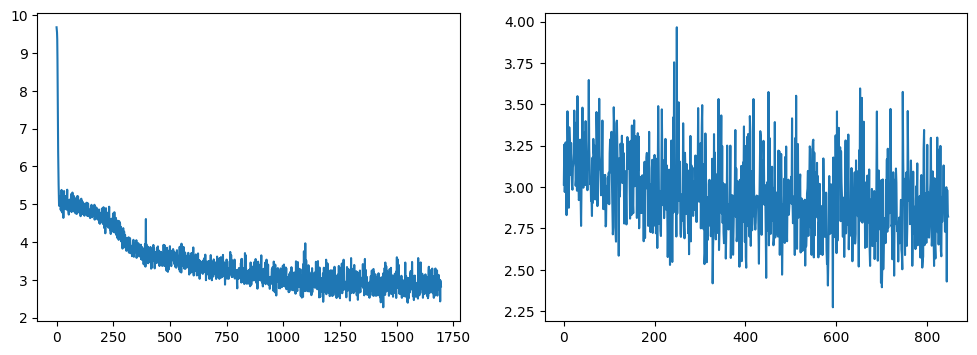

In [39]:
try:
    if train_language_model:
        loss = midnight.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [40]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Midnight._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: midnight.language_model, group='Midnight._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [23]:
try:
    print(midnight.inference('rock', ['black', 'enter', 'spell', 'priests', 'dragon'], starting_words='', max_len=400).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1182: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


<SONG_START> if you can take another more
if we both know when "
how much of the old people are going to be ?
you are , we have been freely to stay
for people who left the time and we
so many questions that the story was right before the sun ?
there is already been in the old day
but how happened this world ? ?
and they " ll never help it again
what " s you , they are ?
when we " ll bring my hand on  " the best way over the city where my life is !
" [ ? ] " there comes a song to be free
my " s through a house are you "
the last one is my heart in home is ,
<CHORUS>
if am where you " re not to have , what did they say me ?
how for it is so many people are ?
because ?
are the real people i will say that ?
it " s the same , our friends are
<BRIDGE>
and you're the only one who had known <NEW_


In [49]:
try:
    _songs = midnight.bulk_inference(
                            genres="rock",
                            context_words="fight life death play fun sing joy",
                            max_len=500,
                            temperature=1.0,
                            top_k=20,
                            n_songs=5,
                            )
    for i, s in enumerate(_songs):
        print("SONG ", i + 1)
        print(s)
        print()
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1182: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


SONG  1
i am the love of you but i " m a friend - and in my side of the day
i " m just in the end of your head , you " re not your fault
i " m in the dark
you are a - the world , i , all i fall
you are me i , i " ll be there
you are a little good man
i know i don " t know if i feel
i know , when you see me ?

you say my face , we never need me now
i have no one will have to find this world i
i think it was true

i know that i am born for an one i love the way you
it " s a beautiful heart of the time you can feel a song
it " s a place that i was born for one to ever
my time you can " t be with you and you
no i " m going to keep this in that way it " s alright

i " m in that day and you " s all in your love
you are my friend !
i " ve always known to say to the way you need
when we " re always on your mind , when your heart was so good
that you " ll be
i will see you on this always
the way you make the chance to find me
i used

SONG  2

you could be just a lot of you
you've never seen a n

In [47]:
try:
    # print(midnight.ds_data.iloc[42]['lyrics'].replace(' <NEW_LINE> ', '\n'))
    print(midnight.annotate_text(4432))
except:
    traceback.print_exc()

Annotation(lyrics_id=4432, genre='rock', keywords=['drying', 'fish', 'unforgiving', 'sacrifice', 'flesh'])


In [59]:
from aspect_tetra import SolutionEvaluator

In [60]:
try:
    evaluator = SolutionEvaluator(midnight)
except:
    traceback.print_exc()

In [52]:
try:
    bertscore = evaluator.compute_bertscore()
    print(bertscore)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1182: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-

{'precision': np.float64(0.7578315436840057), 'recall': np.float64(0.6653476417064667), 'f1': np.float64(0.7080511450767517)}


In [54]:
try:
    mauve = evaluator.compute_mauve()
    print(mauve)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1182: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
Featurizing q: 100%|██████████| 10/10 [00:18<00:00,  1.83s/it]
C

0.6833132973741672


In [63]:
try:
    perplexity = evaluator.compute_perplexity(collate=evaluator.default_collate)
    print(perplexity)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1182: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


9.710950136184692


In [64]:
try:
    self_bleu = evaluator.compute_self_bleu()
    print(self_bleu)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1182: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


0.09731019934249503


In [69]:
try:
    print("Bert Score:")
    print(f" * Precision : {bertscore['precision']:.3f}")
    print(f" * Recall    : {bertscore['recall']:.3f}")
    print(f" * F1 Measure: {bertscore['f1']:.3f}")
    print(f"Mauve Score  : {mauve:.3f}")
    print(f"Perplexity   : {perplexity:.3f}")
    print(f"Self BLUE    : {self_bleu:.3f}")
except:
    traceback.print_exc()

Bert Score:
 * Precision : 0.758
 * Recall    : 0.665
 * F1 Measure: 0.708
Mauve Score  : 0.683
Perplexity   : 9.711
Self BLUE    : 0.097
